# Understanding of OSM

## 1. What OpenStreetMap is

OSM is:

* A **global geospatial database**
* Stores real-world objects (roads, buildings, cities, etc.)
* Built from:

  * **Geometry** (where + shape)
  * **Tags** (what the object represents)


## 2. Geometry (Where is it? What shape does it have?)

Geometry describes the spatial structure of objects.

### Node (Point)

A node contains coordinates:

```json
{
  "lat": 32.0853,
  "lon": 34.7818
}
```

👉 Represents a single location (e.g., cafe, bus stop)

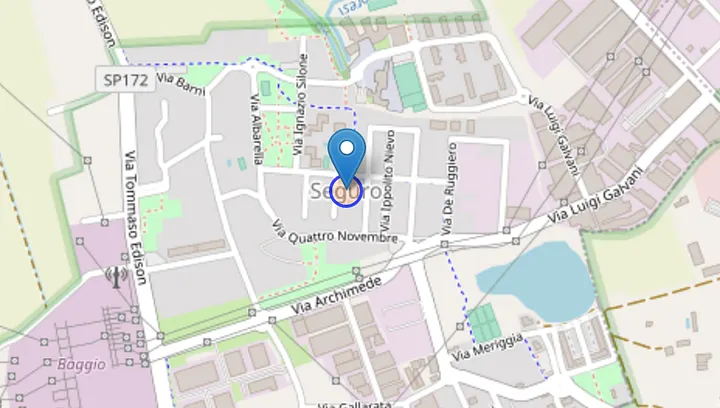

### Way (Line / Polygon)

A way is an ordered list of nodes:

```text
Node1 → Node2 → Node3 → Node4
```

* If open → represents a **line** (road, river)
* If closed → represents a **polygon**:

```text
Node1 → Node2 → Node3 → Node4 → Node1
```

👉 Represents:

* buildings
* parks
* areas




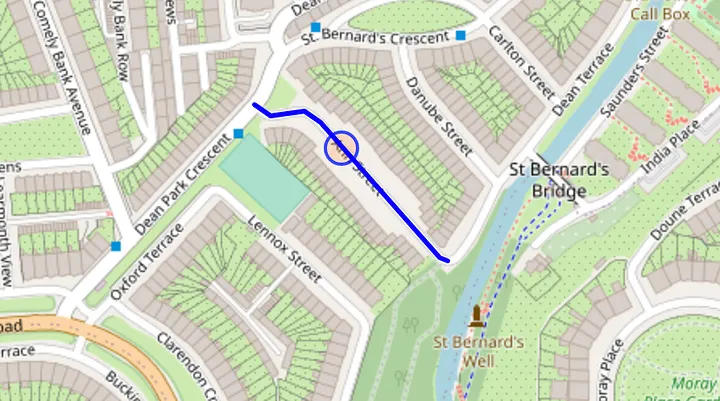
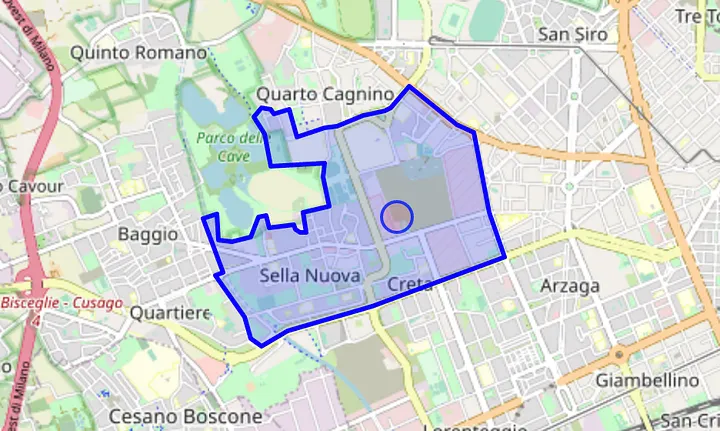

### Relation (Complex structures)

A relation is a collection of nodes and/or ways, each with a **role**.

Used for:

* boundaries (countries, cities)
* turn restrictions (navigation logic)
* complex geometries (e.g., multipolygons)

👉 Example:

* A city boundary composed of multiple ways
* A building with holes (inner + outer polygons)

👉 Note:
Relations are more complex and less critical at the initial stage, but important for full data understanding.
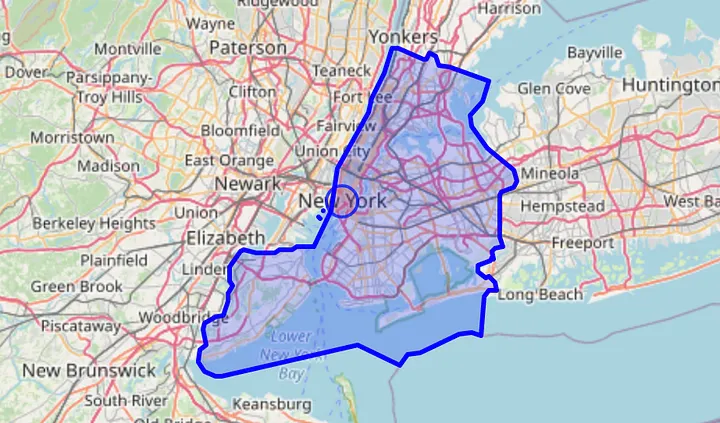

### Key Point:

👉 Geometry alone does **not** define what an object is — only its shape and location.


## 3. Tags (What is it?)

Tags provide the semantic meaning of an object.

Format:

```text
key = value
```

Examples:

```text
highway = residential
name = Herzl Street
```

```text
amenity = cafe
name = Coffee Lab
```

👉 Tags define:

* type (road, cafe, building, etc.)
* attributes (name, usage, etc.)


## 4. Combining Geometry + Tags

Only when combining both do we get meaningful real-world objects.


### Example:

**Geometry:**

```text
(lat, lon) = (32.07, 34.78)
```

**Tags:**

```text
amenity = cafe
name = Coffee Lab
```

👉 Result:

> A cafe named *Coffee Lab* at this location


## 5. Key Insight

* Geometry = **where + shape**
* Tags = **meaning**
* Relations = **complex structures built from multiple elements**

Together, they form a flexible and expressive geospatial data model.


Good catch — yeah, you *mentioned* `.pbf` but didn’t really explain it. Adding a short, clear section will make your write-up feel complete and more “professional”.

Here’s a clean addition you can drop in 👇


## 6. OSM Data Formats

OSM data is distributed in different formats, mainly:

### `.osm` (XML format)

* Human-readable text format
* Easy to inspect and understand
* Very large and inefficient for large datasets

👉 Mainly used for:

* debugging
* small-scale examples

### `.pbf` (Protocolbuffer Binary Format)

* Compressed binary format
* Much smaller and faster to process than `.osm`
* Standard format for large-scale OSM data distribution

👉 Characteristics:

* Not human-readable
* Efficient for storage and transfer
* Designed for high-performance parsing

Example use: downloading .pbf files from Geofabrik and importing them into a local database with Nominatim for fast, searchable geospatial queries.

### Key Point

👉 `.pbf` is the **main format used in practice** for:

* downloading OSM data
* building pipelines
* local deployments

# 🗺️ OSM Data + Nominatim Workflow

## 1. Data Sizing / Profiling Before Download

Before downloading large `.pbf` files, it’s good to know:

* **Geofabrik** ([https://download.geofabrik.de/](https://download.geofabrik.de/)) provides:

  * **File size info** for each region (country, state, continent)
  * `.pbf` download links
  * Often updated weekly → ensures fresh data
  * Example: Israel `.pbf` ≈ 50–60 MB (small country, manageable)

* **BBBike extracts** ([https://extract.bbbike.org/](https://extract.bbbike.org/)) allow:

  * Custom bounding boxes
  * Estimates the resulting file size
  * Good for testing small areas

**Tip:** Always check `.pbf` size before committing — full continents or big countries like Germany or the US can be several GBs.


## 2. Download Options

1. **Geofabrik**: best for official, up-to-date `.pbf` files

   * Direct links → fast, reliable
   * Example: `geofabrik.de/asia/israel-latest.osm.pbf`

2. **BBBike / Custom Extracts**: good for small test areas

   * You can specify a bounding box to reduce size
   * Test queries before going country-wide


## 3. Local Nominatim Pipeline

1. **Install PostgreSQL + PostGIS**

   * Needed to store spatial data
2. **Install Nominatim**

   * Will manage the OSM import and provide search endpoints
3. **Import `.pbf`**

   * `osm2pgsql` internally used by Nominatim
   * Builds all required indexes
4. **Build Indexes**

   * Needed for fast search queries
5. **Validate**

   * Search queries: name → coordinates
   * Reverse queries: coordinates → address
6. **Optional EDA**

   * Check coverage, missing tags, or interesting features

## ✅ Notes / Best Practices

* Start small: download a city or region first (Israel → Tel Aviv or Jerusalem)
* `.pbf` is **mandatory** for large datasets; `.osm` is human-readable but slow
* Check disk space: Nominatim import can temporarily need **5–6× the `.pbf` size**
* Profiling size in advance helps avoid surprises during import

# OSM Data Size Overview: Global, Continent, and Country Extracts

OpenStreetMap (OSM) data comes in different forms and sizes, depending on the source and coverage. Here's a clear breakdown:


### 1. **Global `.pbf` files from Geofabrik**

* Geofabrik provides **continent and country extracts**: [https://download.geofabrik.de](https://download.geofabrik.de)  
* As of recent data (~2026):

| Region                   | File Size (.pbf) |
| ------------------------ | ---------------- |
| Europe                   | ~115 GB          |
| Asia                     | ~90 GB           |
| Africa                   | ~30 GB           |
| North America            | ~80 GB           |
| South America            | ~35 GB           |
| Oceania                  | ~10 GB           |
| **World (all combined)** | >360 GB          |

> Note: This is **compressed `.pbf` format**. The **uncompressed `.osm` XML** is 2–3× bigger.

> ⚠️ **Important:** “World (all combined)” is **larger than the Planet file (~90–100 GB)** because it sums all continent/country extracts. This can include overlaps and extra data for each extract, which adds overhead.

### 2. **OSM Planet File**

* The "planet" file contains **all OSM data worldwide**: [https://planet.openstreetmap.org/](https://planet.openstreetmap.org/)  
* Compressed `.pbf`: ~90–100 GB  
* Uncompressed `.osm` XML: ~300–350 GB  
* Updated **weekly**

### 3. **Key Differences: Geofabrik vs Planet**

| Feature                     | Geofabrik “World combined” | OSM Planet File |
|-------------------------------|---------------------------|----------------|
| Source                        | Curated continent/country extracts | Official OSM dump |
| Metadata/extra details        | May omit some history or metadata | Complete, full history & tags |
| File structure                | Multiple smaller files, summed | Single massive file |
| Size (compressed)             | >360 GB                   | ~90–100 GB |
| Ready for selective import    | Yes                       | Less flexible without pre-processing |

> **Tip:** Geofabrik extracts are convenient for EDA and experiments. The Planet file is used for full-scale imports on dedicated servers.

### 4. **Database Size**

* Once imported into **PostGIS/Nominatim**, the data **expands significantly** due to indexes.
* Example: Full planet import into Nominatim → **1–1.2 TB** disk space required.
* Country extracts are much smaller: e.g., Israel `.pbf` → ~115 MB compressed → ~300–400 MB in DB.

**Tips to reduce Nominatim DB size:**

1. **Use only essential features**
   Nominatim lets you **filter which types of OSM data to import**.
   For example, skip historical data, certain relations, or amenities you don’t need.

2. **Disable unused indexes**
   Some indexes are optional (like trigram/full-text for searching).
   If you don’t need extremely fast searches, you can drop some.

3. **Use country extracts instead of Planet**
   Country extracts are already much smaller and avoid building a TB-scale DB for testing.

> ⚠️ Nominatim DB is always bigger than `.pbf` because it’s **optimized for fast queries**, not for storage efficiency.

### 5. **Takeaways**

* **Country extracts** (like Israel, Germany, France) are safe for local setups / Kaggle experiments.  
* **Full planet** is massive — requires **dedicated server** and **lots of RAM/disk**.  
* For EDA, **start with country extracts** first, then scale up if needed.  
* **Geofabrik “World combined”** is larger than Planet due to **summed extracts and minor overlaps**, don’t be alarmed if it exceeds the Planet file size.

# OSM Pre-Download Profiling

The goal of this module is to calculate the total storage requirements for OpenStreetMap (OSM) data across the Middle East and adjacent regions. Since **Geofabrik** (the primary host for OSM PBF files) uses a specific directory structure and regional bundling, a standard URL pattern isn't enough.

### 1. Handling Geofabrik’s Directory Logic
Geofabrik organizes files by continent, but some countries are placed in subdirectories or different continents based on their internal administrative logic:
* **Continent Shifts:** Turkey and Georgia are hosted under `/europe/`, while the rest of the target countries (excluding North Africa) are under `/asia/`.
* **North Africa:** Egypt, Libya, and Sudan are specifically mapped to the `/africa/` directory.

### 2. The GCC Bundle Challenge
Geofabrik does not provide individual `.osm.pbf` files for small Gulf countries. Instead, they bundle **Saudi Arabia, Oman, UAE, Qatar, Kuwait, and Bahrain** into a single regional file: `gcc-states-latest.osm.pbf`.
* **Mapping:** Any request for an individual GCC country is automatically redirected to the `gcc-states` URL.
* **Storage Accuracy:** To avoid inflating the "Total Storage Required" by counting the same ~240 MB file six times, the logic includes a flag to ensure the bundle size is only added to the grand total once.

### 3. Metadata Extraction (The "Profiling")
Instead of downloading the files, we use **HTTP HEAD requests**. This allows us to:
* Verify the URL is valid (avoiding 404 errors).
* Extract the `Content-Length` header to determine the exact file size in bytes.
* Calculate the size in MB for human readability.

### 4. Data Organization & Sorting
The results are processed into **Pandas DataFrames**, partitioned by the region groups (Core, Extended, South Asia, etc.). 
* **Sorting:** Within each group, countries are sorted by file size in descending order, making it easy to identify which regions (like Iran or Pakistan) will take the most time to process.
* **Reporting:** The final output provides a "Grand Total" in GB, allowing for infrastructure planning before the actual download phase begins.

---

### Logic Summary Table

| Case | Geofabrik Path |
| :--- | :--- |
| **Standard Asia** | `https://download.geofabrik.de/asia/{country}-latest.osm.pbf` |
| **Europe Shift** | `https://download.geofabrik.de/europe/{turkey/georgia}-latest.osm.pbf` |
| **North Africa** | `https://download.geofabrik.de/africa/{country}-latest.osm.pbf` |
| **GCC States** | `https://download.geofabrik.de/asia/gcc-states-latest.osm.pbf` |

---

In [ ]:
import pandas as pd
import requests
import json
import os

# ---- Configuration & Persistence ----
BASE_URL = "https://download.geofabrik.de"
CACHE_FILE = "geofabrik_cache.json"

# Load existing cache or initialize
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, 'r') as f:
        profiling_cache = json.load(f)
    print(f"✅ Loaded {len(profiling_cache)} cached regions.")
else:
    profiling_cache = {}
    print("🆕 No cache found. Starting fresh.")

# ---- Regions Data ----
regions = {
    "core_middle_east": [
        "israel-and-palestine", "jordan", "lebanon", "syria", "iraq", 
        "saudi-arabia", "yemen", "oman", "united-arab-emirates", 
        "qatar", "kuwait", "bahrain"
    ],
    "extended_middle_east": ["iran", "turkey"],
    "south_asia": ["afghanistan", "pakistan"],
    "north_africa": ["egypt", "libya", "sudan"],
    "caucasus": ["georgia", "armenia", "azerbaijan"],
    "central_asia": [
        "kazakhstan", "uzbekistan", "turkmenistan", "kyrgyzstan", "tajikistan"
    ]
}

GCC_LIST = ["saudi-arabia", "oman", "united-arab-emirates", "qatar", "kuwait", "bahrain"]

# ---- Logic Functions ----

def get_smart_pbf_url(country, group):
    """Determines the correct Geofabrik URL based on region and bundles."""
    if country in GCC_LIST:
        return f"{BASE_URL}/asia/gcc-states-latest.osm.pbf"

    if group == "north_africa":
        continent = "africa"
    elif country in ["turkey", "georgia"]:
        continent = "europe"
    else:
        continent = "asia"
    
    return f"{BASE_URL}/{continent}/{country}-latest.osm.pbf"

def osm_profiling(region_name, group=None):
    """
    Retrieves metadata including the 'Last-Modified' timestamp.
    Used for Smart Download logic to check for server-side updates.
    """
    link = get_smart_pbf_url(region_name, group=group)
    profile = {"region": region_name, "pbf_link": link}

    try:
        # We always do a HEAD request to check for the latest 'Last-Modified' date
        head = requests.head(link, allow_redirects=True, timeout=10)
        size_bytes = int(head.headers.get('Content-Length', 0))
        last_modified = head.headers.get('Last-Modified', "unknown")
        
        profile['bytes'] = size_bytes
        profile['pbf_size'] = f"{size_bytes/1024/1024:.1f} MB" if size_bytes else "unknown"
        profile['last_modified'] = last_modified
        
    except Exception as e:
        print(f"⚠️ Connection error for {region_name}: {e}")
        profile['bytes'] = 0
        profile['pbf_size'] = "unknown"
        profile['last_modified'] = "unknown"
    
    # Update cache and persist to disk
    profiling_cache[link] = {
        "bytes": profile['bytes'], 
        "pbf_size": profile['pbf_size'],
        "last_modified": profile['last_modified'],
        # Preserve local download status if it exists
        "last_downloaded_at": profiling_cache.get(link, {}).get("last_downloaded_at", None)
    }
    
    with open(CACHE_FILE, 'w') as f:
        json.dump(profiling_cache, f, indent=4)
        
    return profile

def get_region_statistics(regions_dict):
    """Processes all regions and generates sorted DataFrames per group."""
    group_dfs = {}
    total_bytes_accumulated = 0
    added_gcc = False 

    for group_name, countries in regions_dict.items():
        records = []
        for country in countries:
            profile = osm_profiling(country, group=group_name)
            
            current_bytes = profile.get('bytes', 0)
            is_gcc = country in GCC_LIST

            # Total calculation (GCC bundle only added once)
            if is_gcc:
                if not added_gcc:
                    total_bytes_accumulated += current_bytes
                    added_gcc = True
            else:
                total_bytes_accumulated += current_bytes

            if current_bytes == 0:
                print(f"🚨 ERROR: {country} ({group_name}) returned 0.0 MB!")

            records.append({
                "Country": country,
                "Size": profile['pbf_size'],
                "Last_Updated": profile['last_modified'],
                "Type": "GCC Bundle" if is_gcc else "Individual",
                "URL": profile['pbf_link']
            })
            
        # Create DataFrame and sort by size
        df = pd.DataFrame(records)
        df['sort_val'] = df['Size'].apply(lambda x: float(x.replace(' MB', '')) if 'MB' in x else 0)
        df = df.sort_values(by="sort_val", ascending=False).drop(columns=['sort_val']).reset_index(drop=True)
        
        group_dfs[group_name] = df

    total_gb = total_bytes_accumulated / (1024**3)
    return group_dfs, total_gb

# ---- Execution & Display ----

group_dfs, total_gb = get_region_statistics(regions)

print(f"\n{'='*60}")
print(f"🌍 OSM SMART PROFILING REPORT")
print(f"Total Combined Storage: {total_gb:.2f} GB")
print(f"Metadata Cache: {CACHE_FILE}")
print(f"{'='*60}\n")

for group, df in group_dfs.items():
    print(f"📊 Group: {group.replace('_', ' ').title()}")
    try:
        from IPython.display import display
        display(df)
    except ImportError:
        print(df)
    print("\n" + "-"*60 + "\n")

✅ Loaded 22 cached regions.

🌍 OSM SMART PROFILING REPORT
Total Combined Storage: 2.61 GB
Metadata Cache: geofabrik_cache.json

📊 Group: Core Middle East


,Country,Size,Last_Updated,Type,URL
0,united-arab-emirates,237.0 MB,"Wed, 08 Apr 2026 23:02:08 GMT",GCC Bundle,https://download.geofabrik.de/asia/gcc-states-...
1,qatar,237.0 MB,"Wed, 08 Apr 2026 23:02:08 GMT",GCC Bundle,https://download.geofabrik.de/asia/gcc-states-...
2,oman,237.0 MB,"Wed, 08 Apr 2026 23:02:08 GMT",GCC Bundle,https://download.geofabrik.de/asia/gcc-states-...
3,saudi-arabia,237.0 MB,"Wed, 08 Apr 2026 23:02:08 GMT",GCC Bundle,https://download.geofabrik.de/asia/gcc-states-...
4,kuwait,237.0 MB,"Wed, 08 Apr 2026 23:02:08 GMT",GCC Bundle,https://download.geofabrik.de/asia/gcc-states-...
5,bahrain,237.0 MB,"Wed, 08 Apr 2026 23:02:08 GMT",GCC Bundle,https://download.geofabrik.de/asia/gcc-states-...
6,israel-and-palestine,115.2 MB,"Wed, 08 Apr 2026 23:02:01 GMT",Individual,https://download.geofabrik.de/asia/israel-and-...
7,iraq,84.2 MB,"Wed, 08 Apr 2026 23:02:33 GMT",Individual,https://download.geofabrik.de/asia/iraq-latest...
8,syria,74.0 MB,"Wed, 08 Apr 2026 23:03:33 GMT",Individual,https://download.geofabrik.de/asia/syria-lates...
9,lebanon,49.0 MB,"Wed, 08 Apr 2026 23:01:58 GMT",Individual,https://download.geofabrik.de/asia/lebanon-lat...



------------------------------------------------------------

📊 Group: Extended Middle East


,Country,Size,Last_Updated,Type,URL
0,turkey,599.7 MB,"Wed, 08 Apr 2026 23:10:00 GMT",Individual,https://download.geofabrik.de/europe/turkey-la...
1,iran,216.0 MB,"Wed, 08 Apr 2026 23:02:54 GMT",Individual,https://download.geofabrik.de/asia/iran-latest...



------------------------------------------------------------

📊 Group: South Asia


...


------------------------------------------------------------

📊 Group: Caucasus


,Country,Size,Last_Updated,Type,URL
0,georgia,93.6 MB,"Wed, 08 Apr 2026 23:15:15 GMT",Individual,https://download.geofabrik.de/europe/georgia-l...
1,armenia,49.5 MB,"Wed, 08 Apr 2026 23:04:35 GMT",Individual,https://download.geofabrik.de/asia/armenia-lat...
2,azerbaijan,42.7 MB,"Wed, 08 Apr 2026 23:02:11 GMT",Individual,https://download.geofabrik.de/asia/azerbaijan-...



------------------------------------------------------------

📊 Group: Central Asia


,Country,Size,Last_Updated,Type,URL
0,kazakhstan,204.5 MB,"Wed, 08 Apr 2026 23:04:16 GMT",Individual,https://download.geofabrik.de/asia/kazakhstan-...
1,uzbekistan,98.6 MB,"Wed, 08 Apr 2026 23:04:55 GMT",Individual,https://download.geofabrik.de/asia/uzbekistan-...
2,kyrgyzstan,47.3 MB,"Wed, 08 Apr 2026 23:04:49 GMT",Individual,https://download.geofabrik.de/asia/kyrgyzstan-...
3,tajikistan,45.4 MB,"Wed, 08 Apr 2026 23:04:46 GMT",Individual,https://download.geofabrik.de/asia/tajikistan-...
4,turkmenistan,23.0 MB,"Wed, 08 Apr 2026 23:04:18 GMT",Individual,https://download.geofabrik.de/asia/turkmenista...



------------------------------------------------------------



In [ ]:
import os
import requests
from tqdm.auto import tqdm # Progress bar

# for only a small download_pbf   
regions = {
    "central asia": [  
        "turkmenistan"  # smallest country we have here
    ]
}

def download_pbf(url, local_path):
    """Downloads a file with a progress bar."""
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    with open(local_path, "wb") as f, tqdm(
        desc=os.path.basename(local_path),
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = f.write(data)
            bar.update(size)

def smart_download_all(regions_dict, target_dir="osm_data"):
    """
    Checks the cache and local disk to download only new/updated PBFs.
    """
    os.makedirs(target_dir, exist_ok=True)
    downloaded_this_session = set() # Track GCC bundle so we don't download it 6 times

    for group_name, countries in regions_dict.items():
        print(f"\n🚀 Checking Group: {group_name.upper()}")
        
        for country in countries:
            # 1. Get metadata from our existing profiling logic
            profile = osm_profiling(country, group_name)
            url = profile['pbf_link']
            remote_date = profile['last_modified']
            
            # Special handling for GCC: we only want to download the bundle once
            if url in downloaded_this_session:
                print(f"  ⏭️  {country}: Part of a bundle already handled.")
                continue

            local_filename = os.path.basename(url)
            local_path = os.path.join(target_dir, local_filename)
            
            # 2. Check if we need to download
            # Logic: No local file OR remote date != our last recorded download date
            last_recorded_date = profiling_cache.get(url, {}).get("last_downloaded_at")
            
            needs_update = False
            if not os.path.exists(local_path):
                print(f"  📥 {country}: Not found locally. Downloading...")
                needs_update = True
            elif remote_date != last_recorded_date:
                print(f"  🔄 {country}: Update available (Server: {remote_date}). Updating...")
                needs_update = True
            else:
                print(f"  ✅ {country}: Up to date.")

            # 3. Execute Download
            if needs_update:
                try:
                    download_pbf(url, local_path)
                    # Update our cache with the successful download date
                    profiling_cache[url]["last_downloaded_at"] = remote_date
                    with open(CACHE_FILE, 'w') as f:
                        json.dump(profiling_cache, f, indent=4)
                    downloaded_this_session.add(url)
                except Exception as e:
                    print(f"  ❌ Failed to download {country}: {e}")

# ---- Execute ----
# This uses the 'regions' dict from the previous cell
smart_download_all(regions)

C:\Users\talam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🚀 Checking Group: CENTRAL ASIA
  📥 turkmenistan: Not found locally. Downloading...


turkmenistan-latest.osm.pbf: 100%|██████████| 23.0M/23.0M [00:01<00:00, 14.8MiB/s]


In [9]:
# 1. Create the portable image file (approx 360MB)
!docker pull mediagis/nominatim:5.2
!docker save -o nominatim_image.tar mediagis/nominatim:5.2

# 2. Verify it exists
import os
if os.path.exists("nominatim_image.tar"):
    print("✅ Success! Download 'nominatim_image.tar' from the Output sidebar.")    

5.2: Pulling from mediagis/nominatim
4f4fb700ef54: Pulling fs layer
fcc4434da059: Pulling fs layer
5908da1af14f: Pulling fs layer
4f4fb700ef54: Download complete
c1c933df008a: Download complete
fcc4434da059: Download complete
5908da1af14f: Download complete
4f4fb700ef54: Pull complete
5908da1af14f: Pull complete
fcc4434da059: Pull complete
Digest: sha256:3c49ad9443baab1f1ea13a6b1355fa377ae5fb0874dc328cba9b97a0ca7914bb
Status: Downloaded newer image for mediagis/nominatim:5.2
docker.io/mediagis/nominatim:5.2
✅ Success! Download 'nominatim_image.tar' from the Output sidebar.


In [13]:
import os

# 1. Kill the old "nominatim_test" to clear the name
!docker rm -f nominatim_test

# 2. Your confirmed local path
data_dir = r"C:\Users\talam\OneDrive\Documents\GitHub\elastic_search_learn\map_system\osm_data"
pbf_filename = "turkmenistan-latest.osm.pbf"

# 3. Double-check for the 'Blue Cloud' (OneDrive issue)
full_pbf_path = os.path.join(data_dir, pbf_filename)
if os.path.exists(full_pbf_path):
    print(f"✅ Confirmed: File is present ({os.path.getsize(full_pbf_path)/1e6:.2f} MB)")
    
    # 4. Run Docker (Single-line string to avoid Windows shell errors)
    docker_cmd = (
        f'docker run -d '
        f'--name nominatim_test '
        f'-p 8080:8080 '
        f'-e PBF_PATH=/nominatim/data/{pbf_filename} '
        f'-v "{data_dir}":/nominatim/data '
        f'mediagis/nominatim:5.2'
    )
    
    print("🚀 Launching...")
    !{docker_cmd}
else:
    print(f"❌ WAIT: I still can't see the file at {full_pbf_path}")
    print("Check if OneDrive is 'offloading' the file to the cloud!")

✅ Confirmed: File is present (24.08 MB)
🚀 Launching...


Error response from daemon: No such container: nominatim_test


7e7958a8a9fb606daf6f3e3b5d38e4ae299dcf7d58cd1e249594c6974a9e34c7


In [15]:
# This gets the LAST 20 lines without "following" (no hang)
!docker logs --tail 20 nominatim_test

2026-04-09 11:51:14: Done 8080 in 9 @ 924.106 per second - rank 30 ETA (seconds): 19.79
2026-04-09 11:51:15: Done 9020 in 9 @ 954.836 per second - rank 30 ETA (seconds): 18.16
2026-04-09 11:51:16: Done 9960 in 10 @ 981.850 per second - rank 30 ETA (seconds): 16.71
2026-04-09 11:51:16: Done 10940 in 11 @ 1003.918 per second - rank 30 ETA (seconds): 15.36
2026-04-09 11:51:17: Done 11940 in 12 @ 1023.979 per second - rank 30 ETA (seconds): 14.09
2026-04-09 11:51:18: Done 12980 in 12 @ 1040.793 per second - rank 30 ETA (seconds): 12.86
2026-04-09 11:51:19: Done 14020 in 13 @ 1056.806 per second - rank 30 ETA (seconds): 11.68
2026-04-09 11:51:20: Done 15060 in 14 @ 1065.939 per second - rank 30 ETA (seconds): 10.60
2026-04-09 11:51:20: Done 16140 in 15 @ 1089.276 per second - rank 30 ETA (seconds): 9.39
2026-04-09 11:51:21: Done 17220 in 15 @ 1116.137 per second - rank 30 ETA (seconds): 8.19
2026-04-09 11:51:22: Done 18340 in 16 @ 1135.105 per second - rank 30 ETA (seconds): 7.07
2026-04-09

> Note: Accessing https://www.google.com/search?q=http://localhost:8080/search%3Fq%3DAshgabat%26format%3Djson 


> outputs the following: [{"place_id":143862,"licence":"Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright","osm_type":"relation","osm_id":7328329,"lat":"37.9404648","lon":"58.3823487","class":"boundary","type":"administrative","place_rank":8,"importance":0.2933433333333333,"addresstype":"city","name":"Ashgabat","display_name":"Ashgabat, Turkmenistan","boundingbox":["37.7686483","38.1053831","57.9922699","58.4786364"]},{"place_id":148088,"licence":"Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright","osm_type":"relation","osm_id":18734896,"lat":"37.9378322","lon":"58.2359467","class":"boundary","type":"administrative","place_rank":16,"importance":0.18667666666666663,"addresstype":"city_block","name":"Ashgabat City","display_name":"Ashgabat City, Büzmeýin District, Ashgabat, Turkmenistan","boundingbox":["37.7686483","38.1053831","57.9922699","58.4786364"]},{"place_id":190090,"licence":"Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright","osm_type":"way","osm_id":1435543950,"lat":"37.9822009","lon":"65.5887606","class":"boundary","type":"administrative","place_rank":16,"importance":0.18667666666666663,"addresstype":"village","name":"Ashgabat village","display_name":"Ashgabat village, Döwletli District, Lebap Region, Turkmenistan","boundingbox":["37.9740547","37.9866552","65.5829408","65.5939915"]}]



which means Nominatim is up and running!

In [16]:
# -f (force) stops and removes the container in one go
!docker rm -f nominatim_test

print("Container destroyed. Port 8080 is now free.")
# This should show an empty list (just the headers)
!docker ps

nominatim_test
Container destroyed. Port 8080 is now free.
CONTAINER ID   IMAGE     COMMAND   CREATED   STATUS    PORTS     NAMES


In [ ]:
# This combines all individual PBFs into one clean file for Nominatim, removing overlapping nodes at the borders.

def merge_for_nominatim(target_dir="./osm_data"):
    # 2. Define paths
    output_file = os.path.join(target_dir, "middle_east_merged.osm.pbf")
    
    # Get all PBFs except the merged one itself
    files = [os.path.join(target_dir, f) for f in os.listdir(target_dir) 
             if f.endswith('.pbf') and "merged" not in f]

    print(f"🛠️ Merging {len(files)} files into one...")
    
    # Run osmium merge. '--overwrite' is useful if you run this multiple times.
    cmd = ["osmium", "merge"] + files + ["-o", output_file, "--overwrite"]
    
    import subprocess
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode == 0:
        print(f"✅ Success! Merged file saved at: {output_file}")
        print(f"📦 Final Size: {os.path.getsize(output_file)/1024**3:.2f} GB")
    else:
        print(f"❌ Merge failed: {result.stderr}")

# --- Execution ---
updated = smart_download_all(regions)
if updated or not os.path.exists("/kaggle/working/osm_data/middle_east_merged.osm.pbf"):
    merge_for_nominatim()
else:
    print("🚀 Local data is current. No merge needed.")